In [1]:
# LEVEL 1
# TASK 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Dataset .csv")

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [49]:
print("Rows and Columns: ")
print(df.shape)
print("\nColumn Names : ")
print(df.columns)
print("\nDataset Info : ")
print(df.info())
print("\nMissing Values : ")
print(df.isnull().sum())

Rows and Columns: 
(9551, 21)

Column Names : 
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Ve

In [6]:
# Top Cuisines Analysis

cuisines = df['Cuisines'].dropna().str.split(',')
all_cuisines = cuisines.explode()
top_cuisines = all_cuisines.value_counts().head(3)
print("Top 3 Cuisines : ")
print(top_cuisines)

Top 3 Cuisines : 
Cuisines
North Indian    2992
 Chinese        1880
 Fast Food      1314
Name: count, dtype: int64


In [7]:
# Percentage

percentage = (top_cuisines / len(df))*100
print("Percentage : ")
print(percentage)

Percentage : 
Cuisines
North Indian    31.326563
 Chinese        19.683803
 Fast Food      13.757722
Name: count, dtype: float64


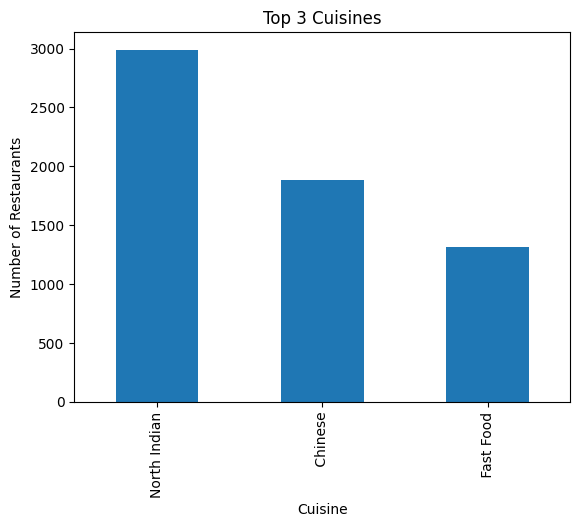

In [8]:
# Visualization

top_cuisines.plot(kind = 'bar')
plt.title("Top 3 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.show()

**Conclusion**:
The analysis shows that North Indian, Chinese, and Fast Food are the top three cuisines. North Indian cuisine is served by the highest number of restaurants, making it the most popular cuisine in the dataset.

In [9]:
# LEVEL 1
# TASK 2

In [10]:
# City Analysis

city_count = df['City'].value_counts()
print("City with Highest Number of Restaurants : ")
print(city_count.head(1))

City with Highest Number of Restaurants : 
City
New Delhi    5473
Name: count, dtype: int64


In [11]:
# Average Rating By City

avg_rating = df.groupby('City')['Aggregate rating'].mean()
print("Average Rating by City : ")
print(avg_rating.sort_values(ascending=False))

Average Rating by City : 
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [12]:
# Highest Average Rating City

highest_rating_city = avg_rating.idxmax()
highest_rating = avg_rating.max()
print("City with Highest Average Rating :")
print("Average Rating:",highest_rating)

City with Highest Average Rating :
Average Rating: 4.9


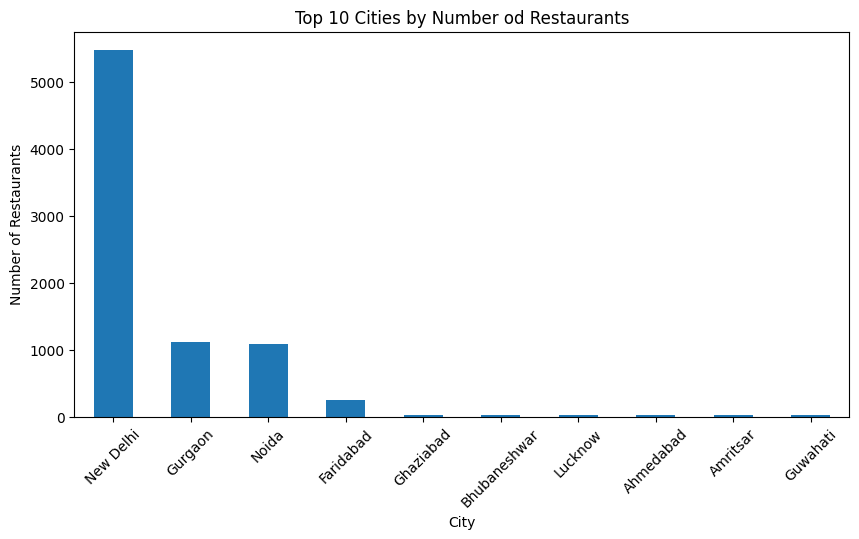

In [13]:
# Visualization 1 Top 10 cities by Number Of Restaurants

top10_cities = df['City'].value_counts().head(10)
plt.figure(figsize=(10,5))
top10_cities.plot(kind='bar')
plt.title("Top 10 Cities by Number od Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

Conclusion:
The analysis shows that New Delhi has the highest number of restaurants, making it the main restaurant hub in the dataset. Additionally, some cities have higher average ratings, indicating better customer satisfaction in those locations.

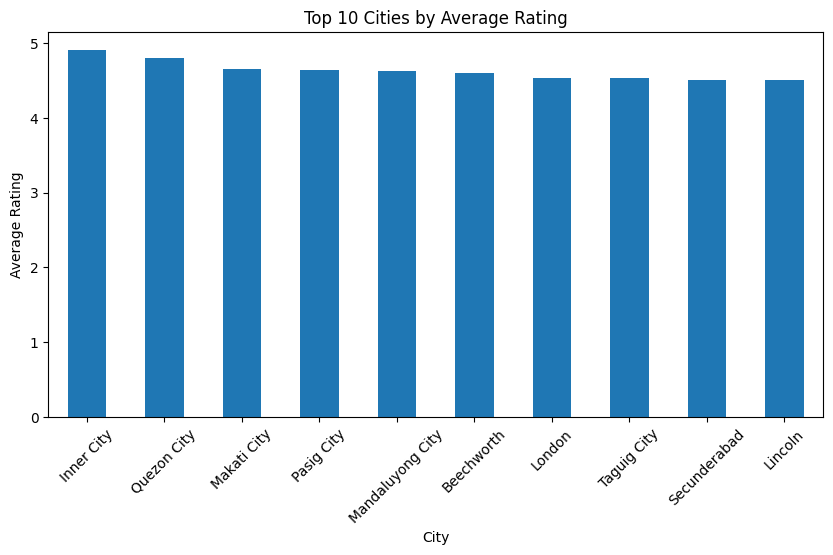

In [14]:
# Visualization 2 Top 10 Cities By Average Rating

top_rating_cities = avg_rating.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_rating_cities.plot(kind='bar')
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

Conclusion:
The analysis of the top 10 cities by average rating shows that certain cities consistently achieve higher ratings, indicating strong customer satisfaction and better overall service quality. These cities likely have businesses that focus more on customer experience, including food quality, service, and ambiance.

In [15]:
# LEVEL 1
# TASK 3

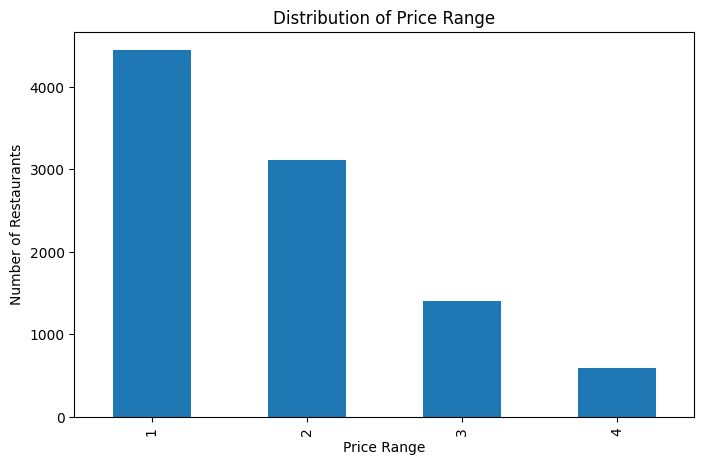

In [16]:
#  Price Range Distribution

price_counts = df['Price range'].value_counts()
plt.figure(figsize=(8,5))
price_counts.plot(kind='bar')
plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()


Conclusion: The analysis of the bar chart shows that restaurants are not evenly distributed across all price ranges. Most restaurants are concentrated in the lower and mid-price categories, indicating higher customer demand in these segments, while fewer restaurants fall into the higher price ranges.

In [17]:
# Percentage of Price Range

price_percentage = (price_counts / len(df))*100
print("Percentage of Restaurants in Each Price Range:\n")
print(price_percentage)

Percentage of Restaurants in Each Price Range:

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


In [18]:
# LEVEL 1
# TASK 4

In [19]:
# Percentage of restaurants with online delivery

online_counts = df['Has Online delivery'].value_counts()
online_percentage = (online_counts / len(df))*100
print("Percentage of Online Delivery:\n")
print(online_percentage)

Percentage of Online Delivery:

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64


In [20]:
# Average rating comparison

avg_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\nAverage Rating Comparison:\n")
print(avg_rating)


Average Rating Comparison:

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


Conclusion: The analysis shows that only a portion of restaurants offer online delivery services. Restaurants with online delivery tend to have slightly higher average ratings compared to those without online delivery, indicating better customer satisfaction and convenience.

In [21]:
# LEVEL 2
# TASK 1

In [22]:
# Rating Distribution

rating_dist = df['Aggregate rating'].value_counts().sort_index()
print(rating_dist)

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


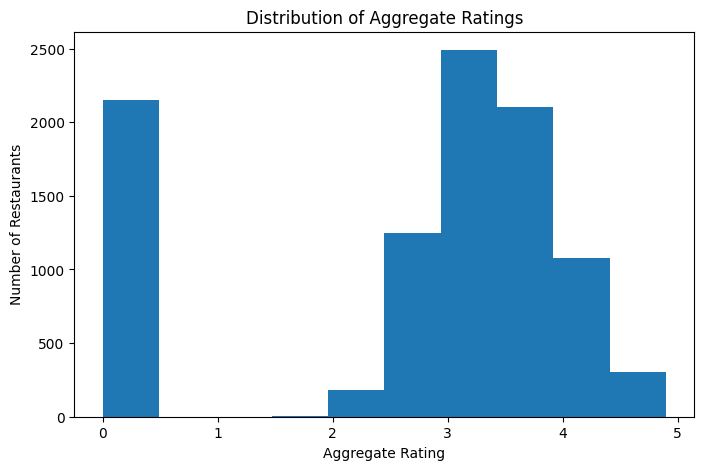

In [23]:
# Visualization of Distribution of Aggregate Ratings

plt.figure(figsize=(8,5))
plt.hist(df['Aggregate rating'],bins=10)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

In [24]:
# Most Common Rating Range

rating_range = pd.cut(
    df['Aggregate rating'],
    bins=[0,1,2,4,5]
)
print(rating_range.value_counts())

Aggregate rating
(2, 4]    6279
(4, 5]    1114
(1, 2]      10
(0, 1]       0
Name: count, dtype: int64


In [25]:
# Average Number of Votes

avg_votes = df['Votes'].mean()
print("Average Votes : ",avg_votes)

Average Votes :  156.909747670401


Conclusion:
The distribution of aggregate ratings shows that most restaurants fall within a moderate rating range. The average number of votes indicates the overall customer engagement level across restaurants. Higher-rated restaurants generally tend to attract more customer attention and feedback.

In [26]:
# LEVEL 2
# TASK 2

In [27]:
# Most Common Cuisine Combinations

top_combinations = df['Cuisines'].value_counts().head(10)
print("Top 10 Cuisine Combinations : ")
print(top_combinations)

Top 10 Cuisine Combinations : 
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


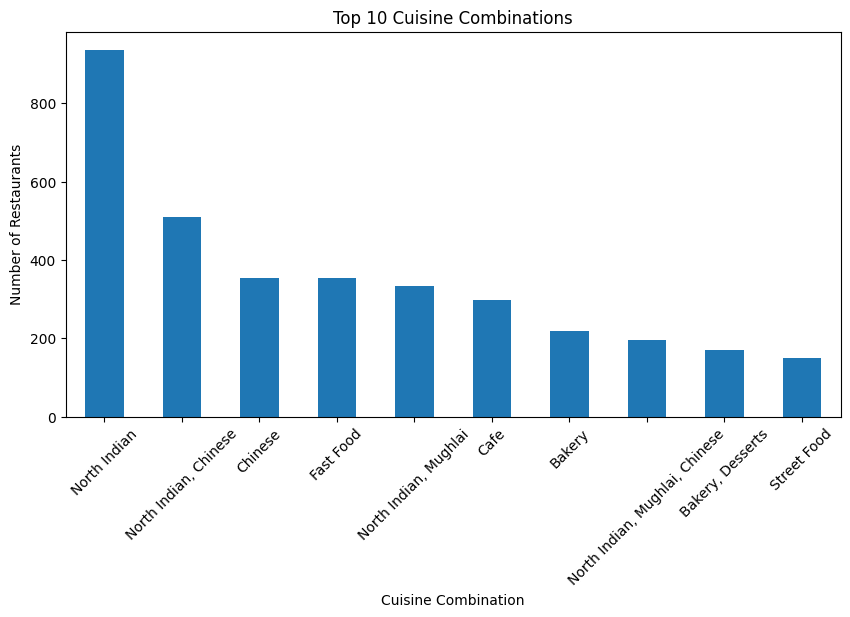

In [28]:
# Visualization of Top 10 Cuisine Combinations

plt.figure(figsize=(10,5))
top_combinations.plot(kind='bar')
plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Highest Rated Cuisine Combinations

top_rated = df.groupby('Cuisines')['Aggregate rating'].agg('mean')
top_rated = top_rated.sort_values(ascending=False).head(10)
print("Top Rated Cuisine Combinations : ")
print(top_rated)

Top Rated Cuisine Combinations : 
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


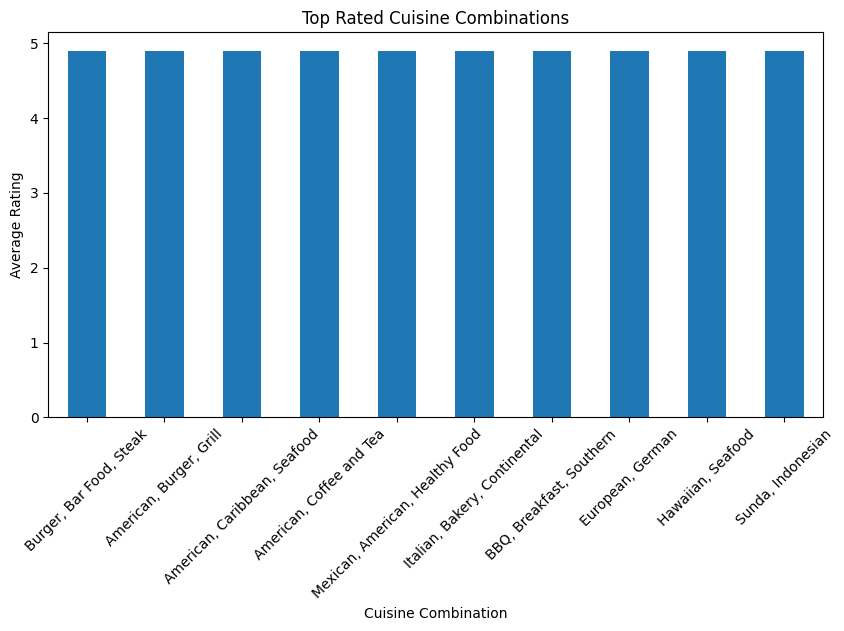

In [30]:
# Visualization of Top Rated Cuisine Combinations

plt.figure(figsize=(10,5))
top_rated.plot(kind='bar')
plt.title("Top Rated Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

Conclusion:
The analysis shows that certain cuisine combinations are more frequently offered by restaurants, while some combinations achieve higher customer ratings. This indicates that popularity and customer satisfaction do not always follow the same trend.

In [31]:
# LEVEL 2
# TASK 3

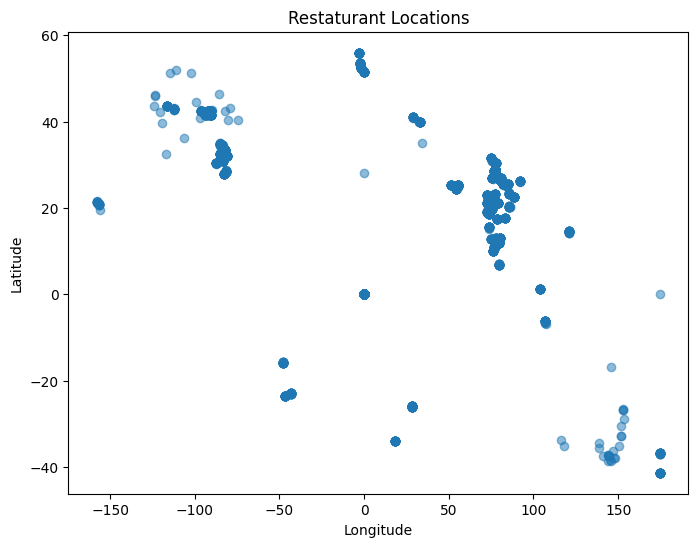

In [33]:
# Geographic Analysis
# Plot Restaurant Locations

plt.figure(figsize=(8,6))
plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)
plt.title("Restaturant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Conclusion:
The geographic analysis shows that restaurants are not evenly distributed across all locations. Several dense clusters of restaurants are concentrated in specific regions, indicating areas with higher restaurant activity and customer demand. The presence of these clusters suggests that restaurants are more commonly located in urban and commercially active areas, while fewer restaurants are found in less populated regions.

In [ ]:
# LEVEL 2
# TASK 4

In [34]:
# Identify Restaurant Chains

chain_count = df['Restaurant Name'].value_counts()
chains = chain_count[chain_count > 1]
print("Restaurant Chains : ")
print(chains.head(10))

Restaurant Chains : 
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [36]:
# Top Restaurant Chains

top_chains = df['Restaurant Name'].value_counts().head(10)
print(top_chains)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


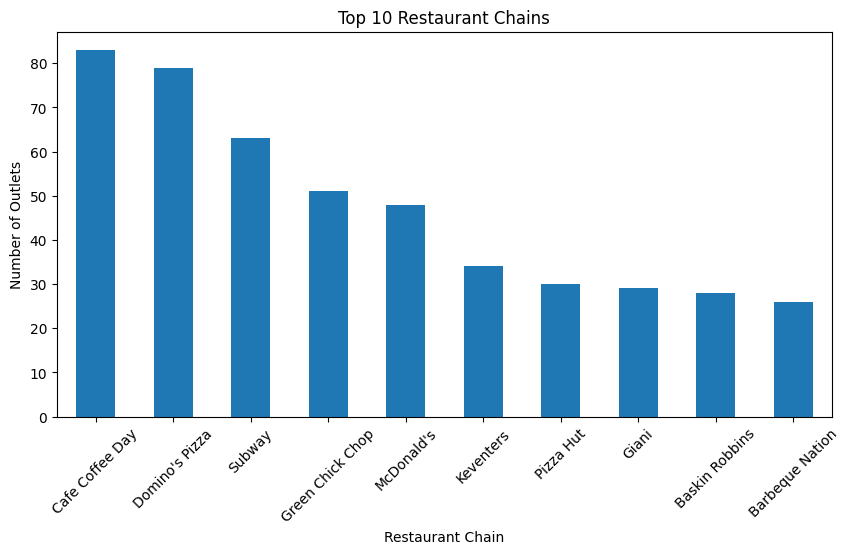

In [38]:
# Visualization of Top 10 Restaurant Chains

plt.figure(figsize=(10,5))
top_chains.plot(kind='bar')
plt.title("Top 10 Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")
plt.xticks(rotation=45)
plt.show()

In [39]:
# Analyze Ratings of Restaurant Chains

chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()
top_chain_ratings = chain_ratings.sort_values(ascending=False).head(10)
print(top_chain_ratings)

Restaurant Name
Solita                                      4.9
Spiral - Sofitel Philippine Plaza Manila    4.9
Flat Iron                                   4.9
Sagar Gaire Fast Food                       4.9
Bao                                         4.9
Yellow Dog Eats                             4.9
Gaga Manjero                                4.9
Sushi Masa                                  4.9
Shorts Burger and Shine                     4.9
Sheroes Hangout                             4.9
Name: Aggregate rating, dtype: float64


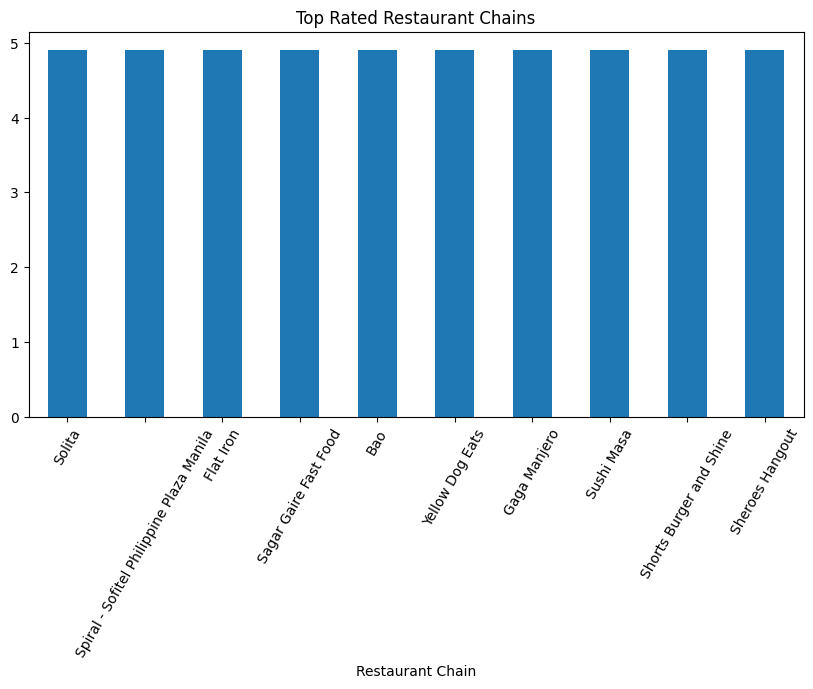

In [44]:
# Visualization of Top Rated Restaurant Chains

plt.figure(figsize=(10,5))
top_chain_ratings.plot(kind='bar')
plt.title("Top Rated Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.xticks(rotation=60)
plt.show()

In [46]:
# Analyze Popularity (Votes)

chain_votes = df.groupby('Restaurant Name')['Votes'].sum()
top_chain_votes = chain_votes.sort_values(ascending=False).head(10)
print(top_chain_votes)

Restaurant Name
Barbeque Nation              28142
AB's - Absolute Barbecues    13400
Toit                         10934
Big Chill                    10853
Farzi Cafe                   10098
Truffles                      9682
Chili's                       8156
Hauz Khas Social              7931
Joey's Pizza                  7807
Peter Cat                     7574
Name: Votes, dtype: int64


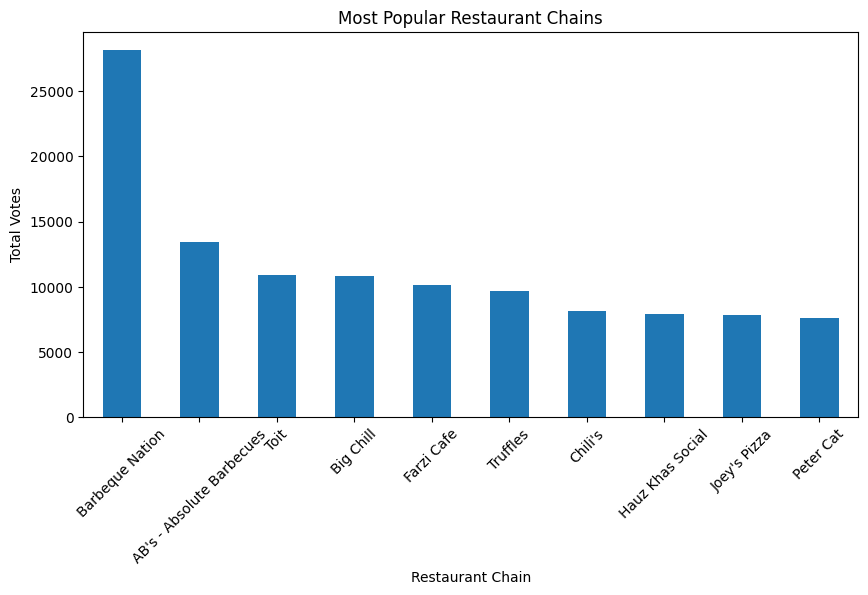

In [48]:
# Visualization of Most Popular Restaurant Chains

plt.figure(figsize=(10,5))
top_chain_votes.plot(kind='bar')
plt.title("Most Popular Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Total Votes")
plt.xticks(rotation=45)
plt.show()

Conclusion:
The analysis identified several restaurant chains operating across multiple locations in the dataset. Some chains have a significantly larger number of outlets, indicating a stronger market presence. The ratings analysis shows that certain chains consistently maintain high customer satisfaction, while the popularity analysis based on votes highlights the chains that receive the highest customer engagement. Overall, restaurant chains with strong ratings and high vote counts tend to have greater customer trust and popularity.